In [176]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import category_encoders as ce
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy.stats import spearmanr
import scipy.stats as stats
import shap
from xgboost import XGBRegressor, DMatrix
from haversine import haversine_vector, Unit
import statsmodels.api as sm

# 1단계) 필수전처리 

데이터로드 - 거리정보처리 - 테이블병합 - 파생변수(배송시간,배송비비율,거리 등 + 배송완료건 필터링) & 결측치제거 - 데이터 정제

In [177]:
# 1. 테이블 load

# Orders
orders = pd.read_csv("data/olist_orders_dataset.csv")

# Order Items
items = pd.read_csv("data/olist_order_items_dataset.csv")

# Order Reviews
reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")

# Products
products = pd.read_csv("data/olist_products_dataset.csv")

# Sellers
sellers = pd.read_csv("data/olist_sellers_dataset.csv")

# Customers
customers = pd.read_csv("data/olist_customers_dataset.csv")

# Geolocation
geo = pd.read_csv("data/olist_geolocation_dataset.csv")

# Product Category Translation
category_translation = pd.read_csv("data/product_category_name_translation.csv")

# Order Payments
payments = pd.read_csv("data/olist_order_payments_dataset.csv")

In [178]:
# 2. 전처리
orders = orders.copy()
items = items.copy()
reviews = reviews.copy()

# 배송 완료된 주문 ID만 추출
orders = orders[orders['order_status'] == 'delivered'].copy()

# 날짜형 변환
order_date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in order_date_cols:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col], errors='coerce')

review_date_cols = ["review_creation_date", "review_answer_timestamp"]
for col in review_date_cols:
    if col in reviews.columns:
        reviews[col] = pd.to_datetime(reviews[col], errors="coerce")

# 2단계) EDA(패턴확인)

### 1. 판매 규모 _ 총매출, 판매량, 판매건수

In [179]:
# 1. 배송 완료된 아이템 데이터 필터링
items_delivered = items[items['order_id'].isin(orders['order_id'])].copy()

# 2. 판매자별(seller_id) 판매 규모 집계
seller_sales_stats = items_delivered.groupby('seller_id').agg(
    total_sales=('price', 'sum'),
    order_count=('order_id', 'nunique'),
    item_count=('order_id', 'size') 
).reset_index()

# 3. 데이터 확인
print(f"전체 판매자 수: {len(seller_sales_stats)}명")
display(seller_sales_stats.describe())

전체 판매자 수: 2970명


,total_sales,order_count,item_count
count,2970.000000,2970.000000,2970.000000
mean,4451.682865,32.935690,37.103367
std,13926.965314,105.407111,119.672968
min,6.500000,1.000000,1.000000
25%,219.800000,2.000000,2.000000
50%,846.175000,7.000000,8.000000
75%,3497.880000,22.000000,26.000000
max,226987.930000,1819.000000,1996.000000


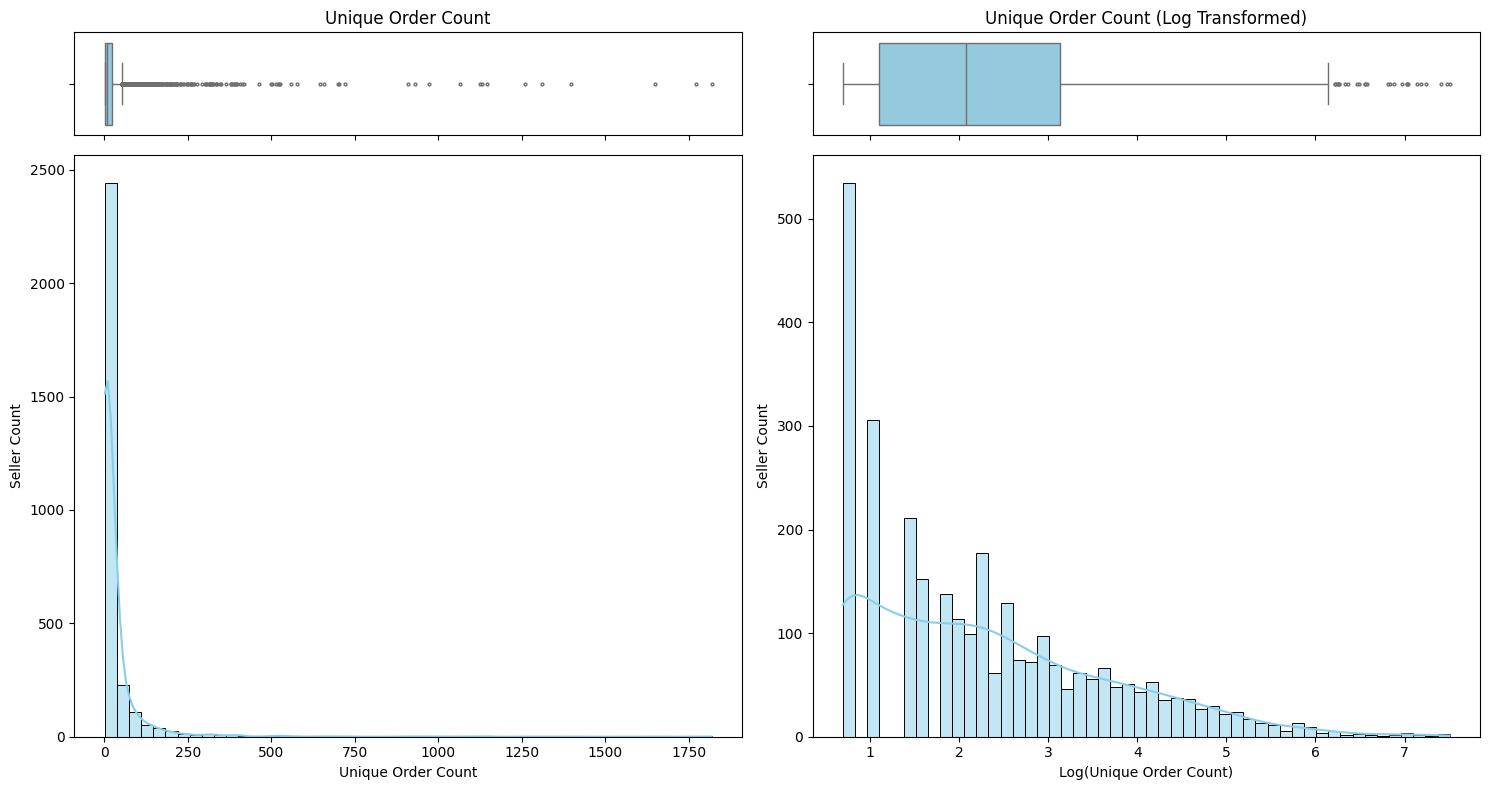

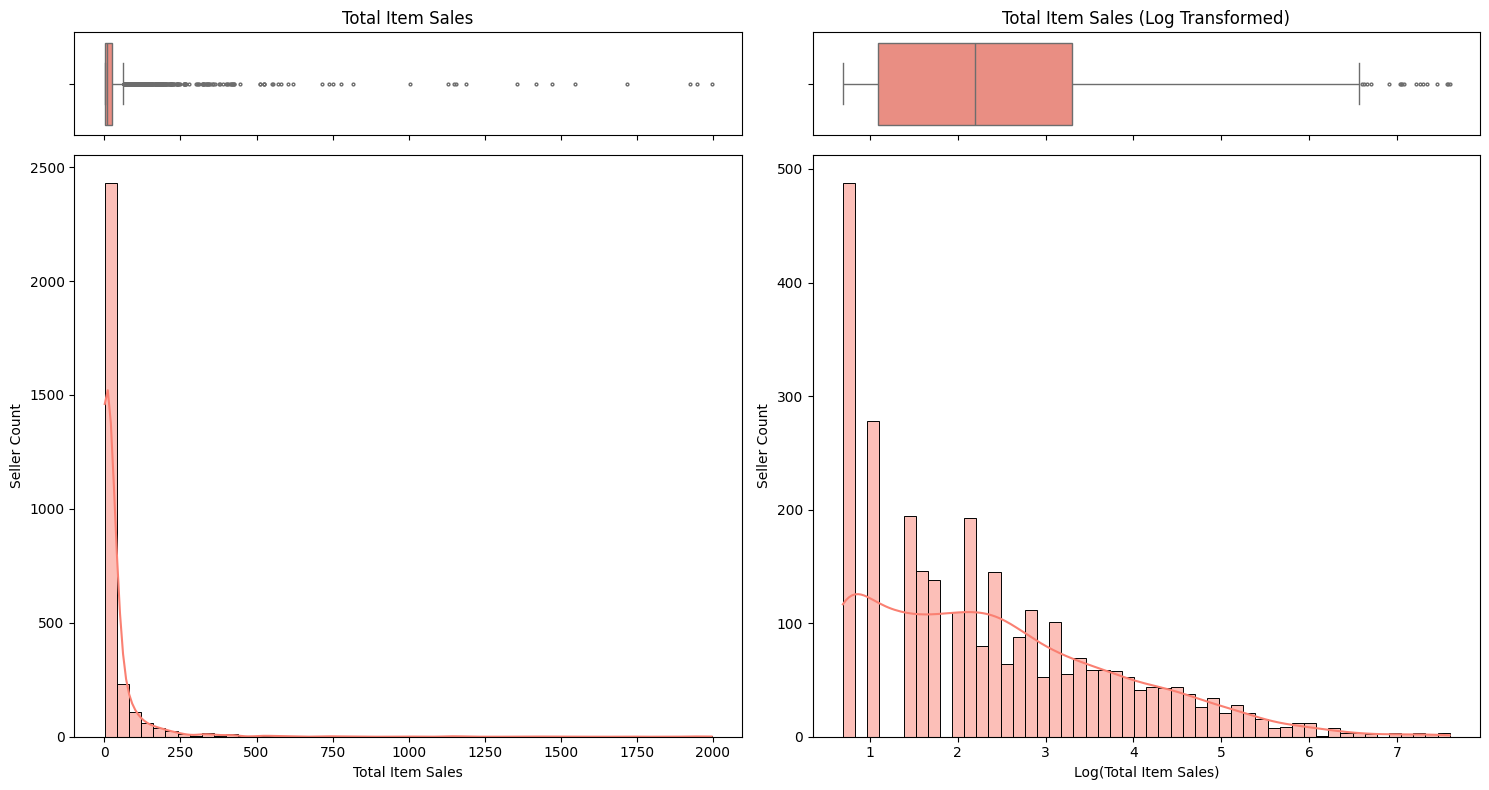

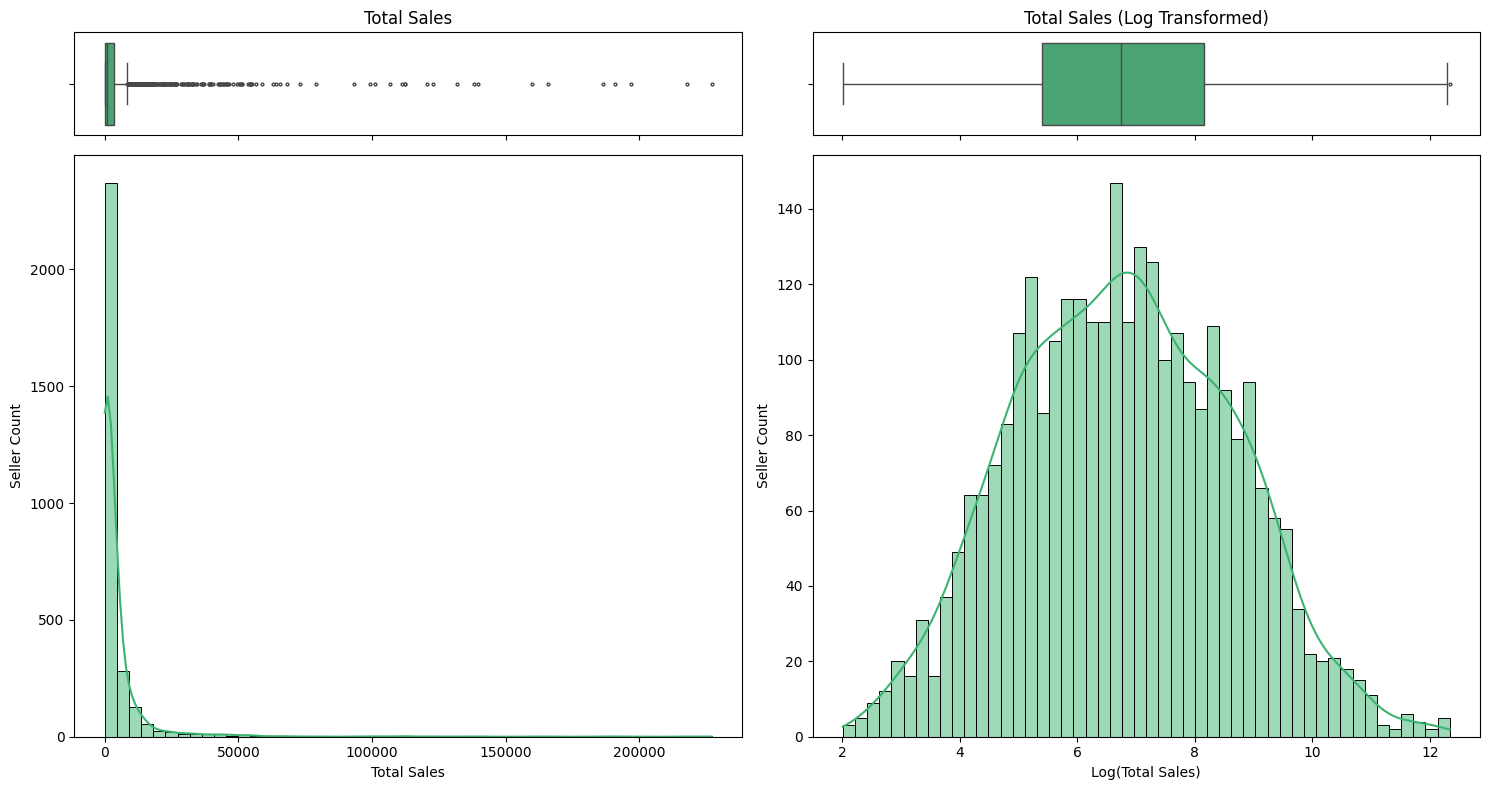

In [180]:
# boxplot + histogram + 로그변환 histogram
features = [
    ('order_count', 'Unique Order Count', 'skyblue'),
    ('item_count', 'Total Item Sales', 'salmon'),
    ('total_sales', 'Total Sales', 'mediumseagreen')
]

for col, title, color in features:
    fig, axes = plt.subplots(2, 2, figsize=(15, 8), 
                             gridspec_kw={"height_ratios": (.15, .85)},
                             sharex='col') 

    sns.boxplot(x=seller_sales_stats[col], ax=axes[0, 0], color=color, fliersize=2)
    axes[0, 0].set(title=f"{title}", xlabel='')
    
    sns.histplot(x=seller_sales_stats[col], ax=axes[1, 0], bins=50, kde=True, color=color)
    axes[1, 0].set(xlabel=title, ylabel="Seller Count")

    log_data = np.log1p(seller_sales_stats[col])
    
    sns.boxplot(x=log_data, ax=axes[0, 1], color=color, fliersize=2)
    axes[0, 1].set(title=f"{title} (Log Transformed)", xlabel='')
    
    sns.histplot(x=log_data, ax=axes[1, 1], bins=50, kde=True, color=color)
    axes[1, 1].set(xlabel=f"Log({title})", ylabel="Seller Count")

    plt.tight_layout()
    plt.show()

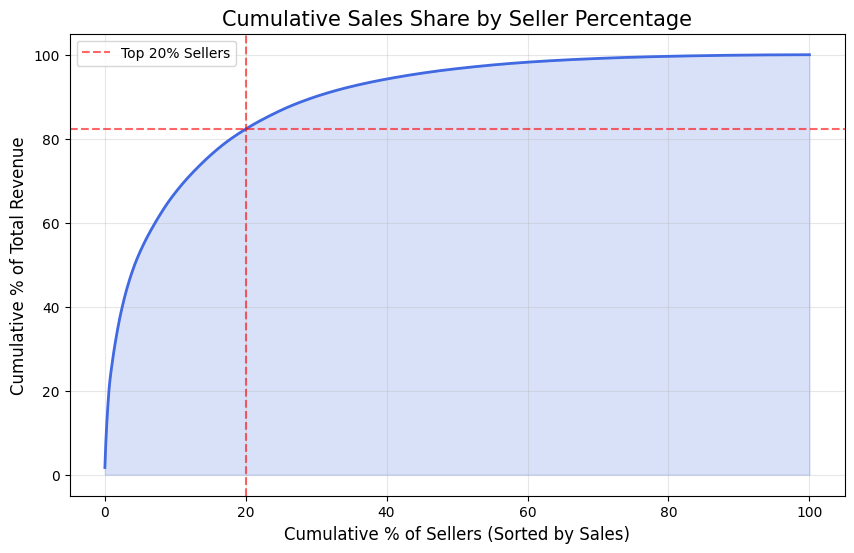

,Top %,Sales Share (%),Seller Count
0,Top 5%,52.94%,148
1,Top 10%,67.11%,297
2,Top 20%,82.29%,594
3,Top 30%,90.05%,891
4,Top 40%,94.21%,1188
5,Top 50%,96.69%,1485


In [181]:
# 판매자 상위 백분위별 매출 점유율 (파레토 분석)
# 1. 매출 기준 내림차순 정렬
df_sorted = seller_sales_stats.sort_values('total_sales', ascending=False).reset_index(drop=True)

# 2. 누적 매출 합계 및 누적 판매자 비중 계산
df_sorted['cum_sales'] = df_sorted['total_sales'].cumsum()
df_sorted['cum_sales_pct'] = df_sorted['cum_sales'] / df_sorted['total_sales'].sum() * 100
df_sorted['cum_seller_pct'] = (df_sorted.index + 1) / len(df_sorted) * 100

# 3. 시각화
plt.figure(figsize=(10, 6))
plt.plot(df_sorted['cum_seller_pct'], df_sorted['cum_sales_pct'], color='royalblue', lw=2)
plt.fill_between(df_sorted['cum_seller_pct'], df_sorted['cum_sales_pct'], alpha=0.2, color='royalblue')

# 80:20 법칙 확인을 위한 가이드라인 (상위 20% 지점)
plt.axvline(x=20, color='red', linestyle='--', alpha=0.6, label='Top 20% Sellers')
plt.axhline(y=df_sorted.iloc[int(len(df_sorted)*0.2)]['cum_sales_pct'], color='red', linestyle='--', alpha=0.6)

plt.title('Cumulative Sales Share by Seller Percentage', fontsize=15)
plt.xlabel('Cumulative % of Sellers (Sorted by Sales)', fontsize=12)
plt.ylabel('Cumulative % of Total Revenue', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 주요 지점(Percentiles) 정의
percentiles = [5, 10, 20, 30, 40, 50]
results = []

total_revenue = seller_sales_stats['total_sales'].sum()
total_sellers = len(seller_sales_stats)

for p in percentiles:
    num_sellers = int(total_sellers * (p / 100))
    top_p_sales = df_sorted.iloc[:num_sellers]['total_sales'].sum()
    share = (top_p_sales / total_revenue) * 100
    results.append({'Top %': f'Top {p}%', 'Sales Share (%)': f'{share:.2f}%', 'Seller Count': num_sellers})

summary_df = pd.DataFrame(results)
display(summary_df)

### 2. 가격 경쟁력 _ 상품가격

In [182]:
# 배송 완료된 아이템 기준
seller_price_stats = items_delivered.groupby('seller_id').agg(
    avg_price=('price', 'mean'),             # 평균 판매 가격
    median_price=('price', 'median'),        # 가격 중앙값 (이상치 영향 적음)
    min_price=('price', 'min'),              # 최저가
    max_price=('price', 'max'),              # 최고가
    std_price=('price', 'std')               # 가격 다양성 (한 우물 vs 여러 종류)
).reset_index()

# 매출 데이터와 합쳐서 '가격 vs 매출' 관계 확인 준비
seller_price_analysis = seller_price_stats.merge(
    seller_sales_stats[['seller_id', 'total_sales', 'order_count', 'item_count']], 
    on='seller_id'
)

# 가격 변동성(CV) 추가: 값이 클수록 다양한 가격대의 상품을 취급함
seller_price_analysis['price_variation'] = (
    seller_price_analysis['std_price'] / seller_price_analysis['avg_price']
).fillna(0)

display(seller_price_analysis.head())

,seller_id,avg_price,median_price,min_price,max_price,std_price,total_sales,order_count,item_count,price_variation
0,0015a82c2db000af6aaaf3ae2ecb0532,895.000000,895.00,895.0,895.00,0.000000,2685.00,3,3,0.000000
1,001cca7ae9ae17fb1caed9dfb1094831,104.645427,99.00,69.9,199.00,15.935771,24487.03,195,234,0.152283
2,002100f778ceb8431b7a1020ff7ab48f,22.529630,17.90,9.9,129.90,19.128460,1216.60,50,54,0.849036
3,003554e2dce176b5555353e4f3555ac8,120.000000,120.00,120.0,120.00,NaN,120.00,1,1,0.000000
4,004c9cd9d87a3c30c522c48c4fc07416,116.486488,109.99,47.9,259.99,45.752425,19569.73,156,168,0.392770


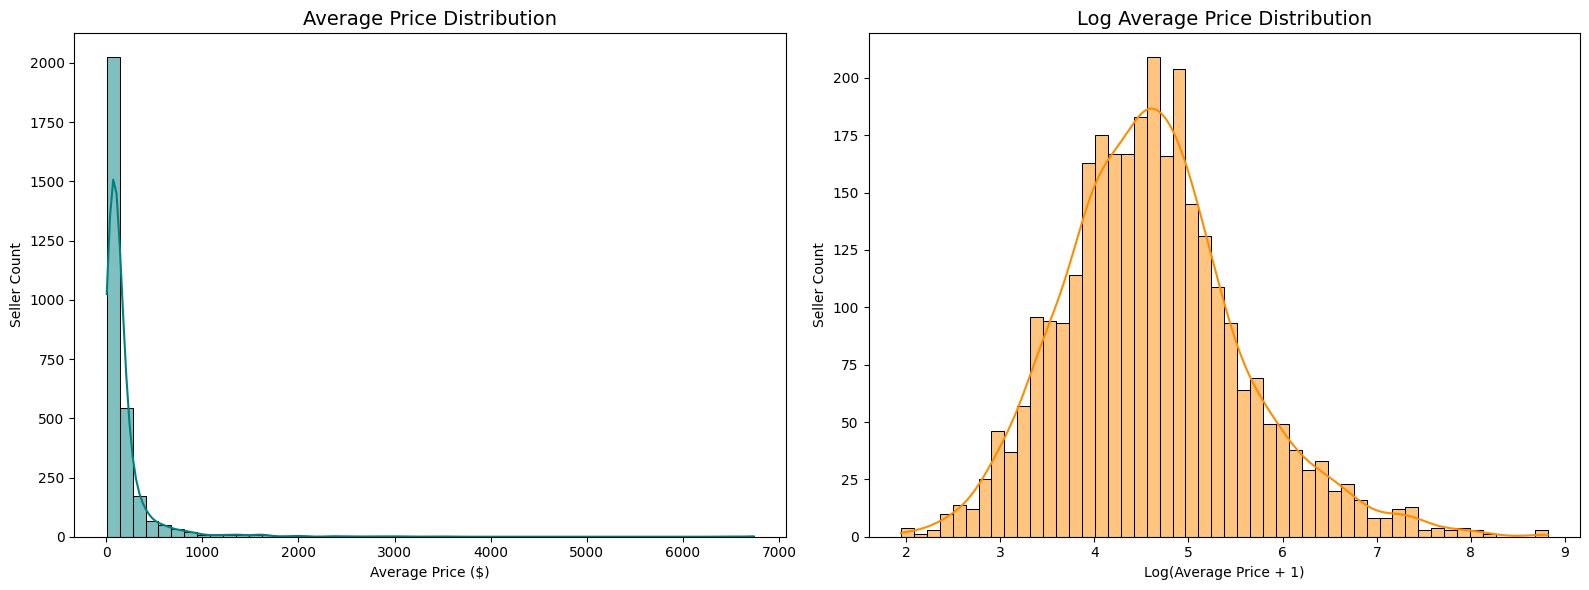

In [183]:
# 가격 히스토그램 + 로그변환 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(seller_price_analysis['avg_price'], bins=50, ax=axes[0], color='teal', kde=True)
axes[0].set_title("Average Price Distribution", fontsize=14)
axes[0].set_xlabel("Average Price ($)")
axes[0].set_ylabel("Seller Count")

sns.histplot(np.log1p(seller_price_analysis['avg_price']), bins=50, ax=axes[1], color='darkorange', kde=True)
axes[1].set_title("Log Average Price Distribution", fontsize=14)
axes[1].set_xlabel("Log(Average Price + 1)")
axes[1].set_ylabel("Seller Count")

plt.tight_layout()
plt.show()

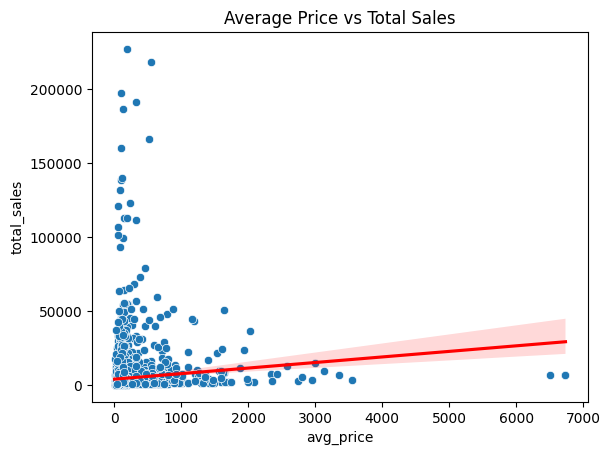

spearman: 0.4854407455733245 p-value: 1.916458888473591e-175


In [ ]:
# 가격과 매출의 상관관계
sns.scatterplot(
    data=seller_price_analysis,
    x='avg_price',
    y='total_sales'
)
sns.regplot(data=seller_price_analysis,
            x='avg_price',
            y='total_sales',
            scatter=False,
            color='red')

plt.title("Average Price vs Total Sales")
plt.show()

corr, p = spearmanr(seller_price_analysis['avg_price'], seller_price_analysis['total_sales'])
print("spearman:", corr, "p-value:", p)

### 3. 배송 품질 _ 배송기간, 배송지연율

In [185]:
# 1. 배송 기간(일) 계산
orders['delivery_duration'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

# 2. 배송 지연 여부 (1: 지연, 0: 정상)
orders['is_late'] = (orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']).astype(int)

# 3. 판매자 정보(items)와 결합하여 집계
seller_delivery = items[['order_id', 'seller_id']].drop_duplicates().merge(
    orders[['order_id', 'delivery_duration', 'is_late']], 
    on='order_id', 
    how='inner'
)

seller_delivery_stats = seller_delivery.groupby('seller_id').agg(
    avg_delivery_time=('delivery_duration', 'mean'),
    late_delivery_rate=('is_late', 'mean'),
    total_orders=('order_id', 'count')
).reset_index()

# 4. 결측치 처리 (배송 기간이 기록되지 않은 경우 제외)
seller_delivery_stats = seller_delivery_stats.dropna()

display(seller_delivery_stats.describe())

,avg_delivery_time,late_delivery_rate,total_orders
count,2970.000000,2970.000000,2970.000000
mean,11.749533,0.084192,32.935690
std,7.161293,0.168742,105.407111
min,1.000000,0.000000,1.000000
25%,8.000000,0.000000,2.000000
50%,10.721895,0.000000,7.000000
75%,13.781401,0.101224,22.000000
max,189.000000,1.000000,1819.000000


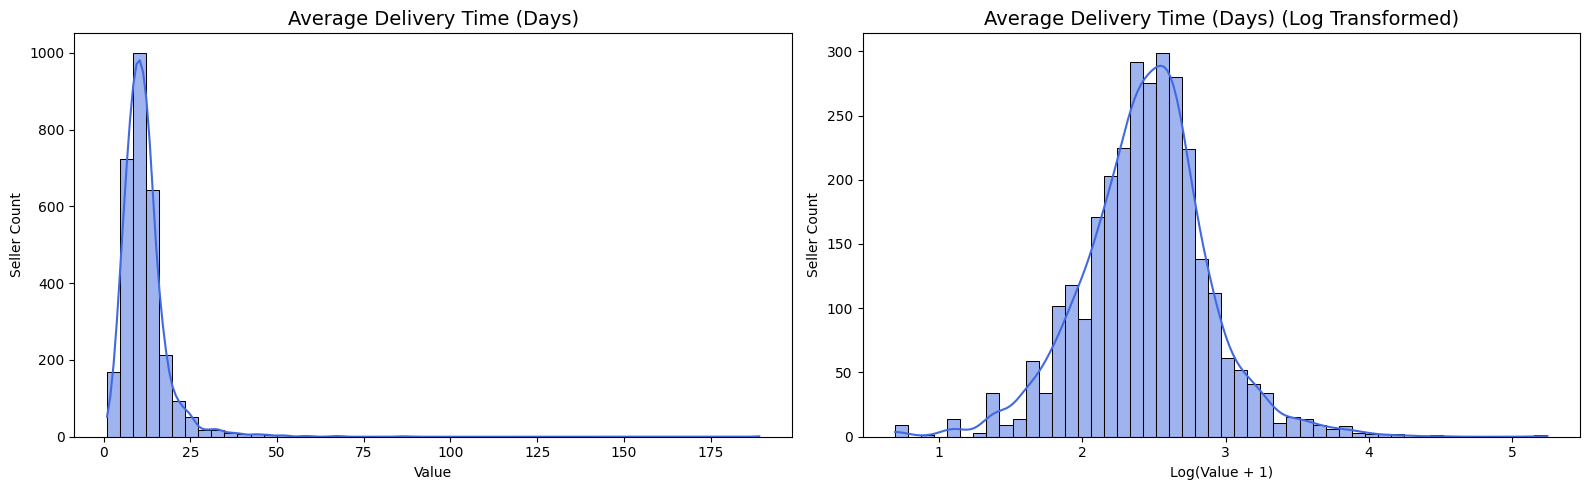

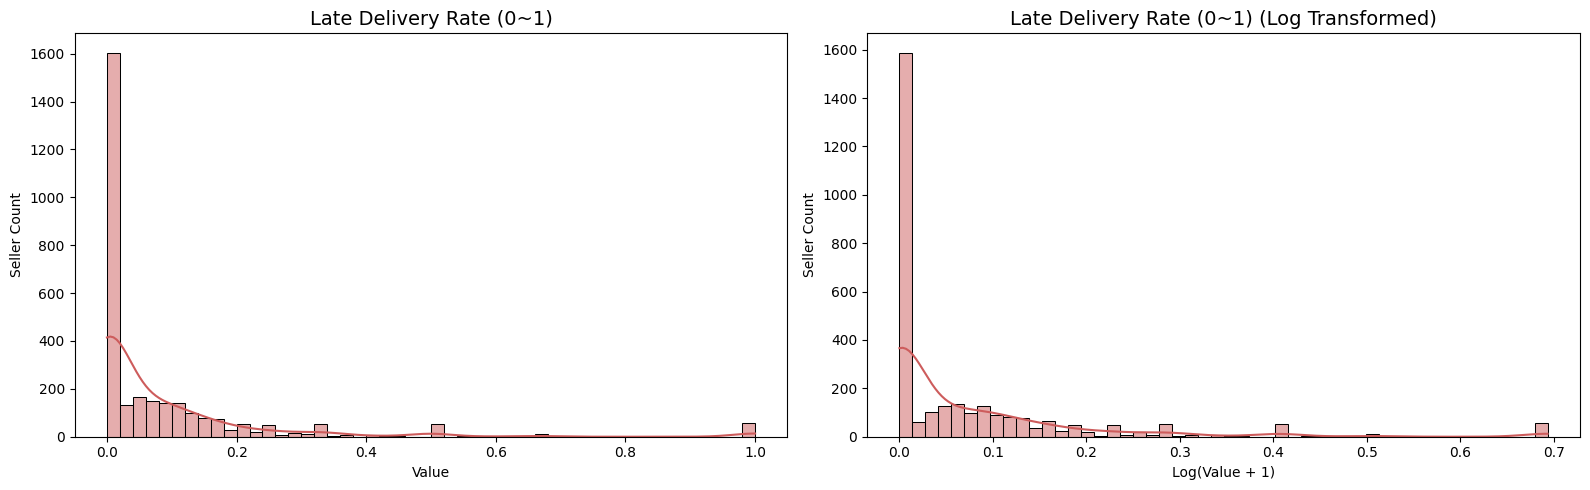

In [186]:
# 평균배송기간, 배송지연율 히스토그램
delivery_features = [
    ('avg_delivery_time', 'Average Delivery Time (Days)', 'royalblue'),
    ('late_delivery_rate', 'Late Delivery Rate (0~1)', 'indianred')
]

for col, title, color in delivery_features:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.histplot(seller_delivery_stats[col], bins=50, kde=True, ax=axes[0], color=color)
    axes[0].set_title(f"{title}", fontsize=14)
    axes[0].set_xlabel("Value")
    axes[0].set_ylabel("Seller Count")
    
    log_data = np.log1p(seller_delivery_stats[col])
    sns.histplot(log_data, bins=50, kde=True, ax=axes[1], color=color)
    axes[1].set_title(f"{title} (Log Transformed)", fontsize=14)
    axes[1].set_xlabel("Log(Value + 1)")
    axes[1].set_ylabel("Seller Count")
    
    plt.tight_layout()
    plt.show()

### 4. 고객 만족 _ 리뷰점수, 리뷰길이

In [187]:
# 1. 리뷰 텍스트 길이 계산 (결측치는 0으로 처리)
reviews['review_length'] = reviews['review_comment_message'].str.len().fillna(0)

# 2. 판매자별 집계 (items_delivered와 병합하여 판매자 정보 가져오기)
seller_review_stats = items_delivered[['order_id', 'seller_id']].drop_duplicates().merge(
    reviews[['order_id', 'review_score', 'review_length']], 
    on='order_id', 
    how='inner'
).groupby('seller_id').agg(
    avg_review_score=('review_score', 'mean'),
    avg_review_length=('review_length', 'mean'),
    review_count=('review_score', 'count')
).reset_index()

display(seller_review_stats.describe())

,avg_review_score,avg_review_length,review_count
count,2965.000000,2965.000000,2965.000000
mean,4.176169,27.681460,32.951771
std,0.774453,28.052846,105.527209
min,1.000000,0.000000,1.000000
25%,3.967742,9.333333,2.000000
50%,4.285714,23.271739,7.000000
75%,4.666667,36.111111,22.000000
max,5.000000,204.000000,1811.000000


/var/folders/54/8xct5w912qbg1y6k2nw1d0xr0000gn/T/ipykernel_48430/3112789906.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=seller_review_stats.assign(score_group=seller_review_stats['avg_review_score'].round()),


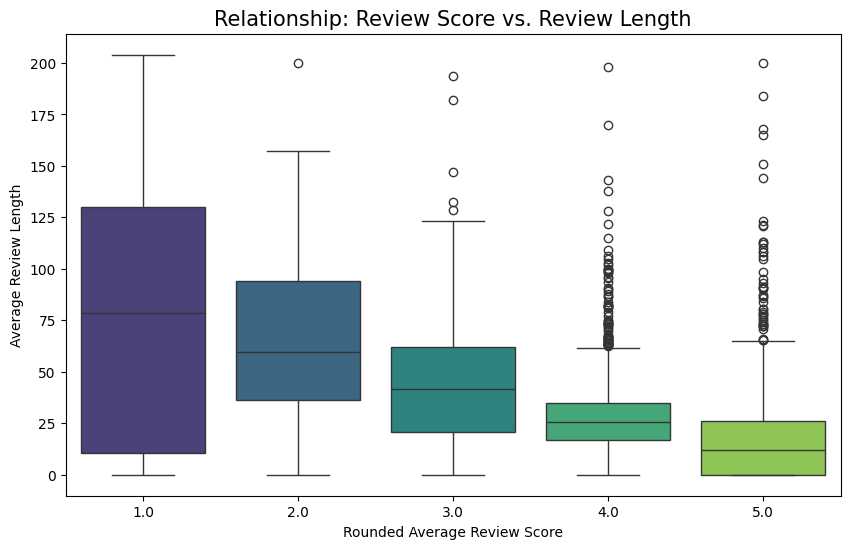

In [188]:
# 리뷰 점수와 길이 간의 관계
plt.figure(figsize=(10, 6))
sns.boxplot(data=seller_review_stats.assign(score_group=seller_review_stats['avg_review_score'].round()), 
            x='score_group', y='avg_review_length', palette='viridis')
plt.title("Relationship: Review Score vs. Review Length", fontsize=15)
plt.xlabel("Rounded Average Review Score")
plt.ylabel("Average Review Length")
plt.show()

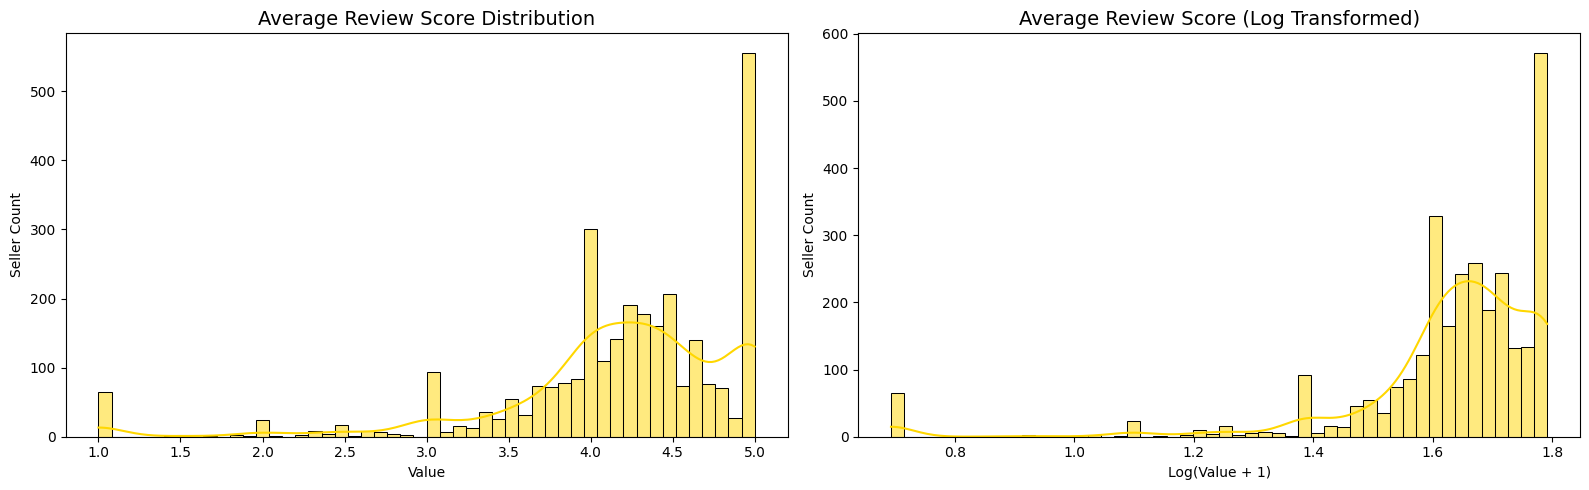

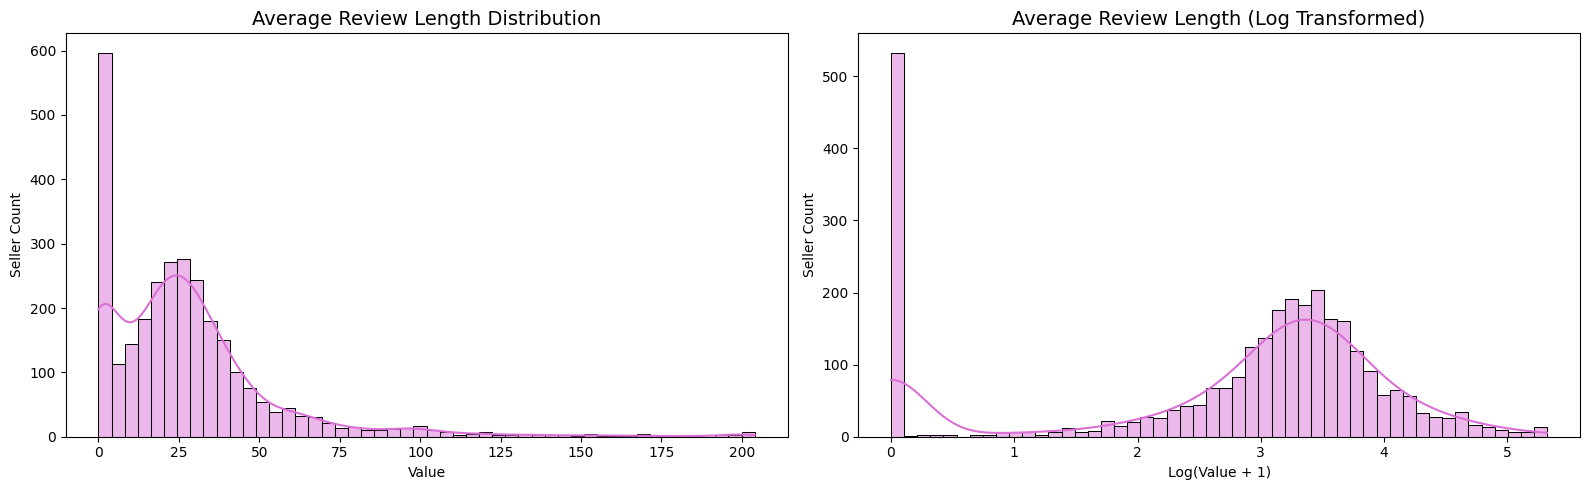

In [189]:
# 평균배송기간, 배송지연율 히스토그램
review_features = [
    ('avg_review_score', 'Average Review Score', 'gold'),
    ('avg_review_length', 'Average Review Length', 'orchid')
]

for col, title, color in review_features:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.histplot(seller_review_stats[col], bins=50, kde=True, ax=axes[0], color=color)
    axes[0].set_title(f"{title} Distribution", fontsize=14)
    axes[0].set_xlabel("Value")
    axes[0].set_ylabel("Seller Count")

    log_data = np.log1p(seller_review_stats[col])
    sns.histplot(log_data, bins=50, kde=True, ax=axes[1], color=color)
    axes[1].set_title(f"{title} (Log Transformed)", fontsize=14)
    axes[1].set_xlabel("Log(Value + 1)")
    axes[1].set_ylabel("Seller Count")
    
    plt.tight_layout()
    plt.show()

### 5. 운영 안정성 _ 상품무게, 상품설명, 주문완료율

In [190]:
# 1. 상품 설명 길이 및 무게 정보 가져오기 (Products table)
products['desc_length'] = products['product_description_lenght'].fillna(0)
products['weight_g'] = products['product_weight_g'].fillna(products['product_weight_g'].median())

# 2. 판매자별 상품 특성 평균 집계
seller_product_stats = items_delivered.merge(
    products[['product_id', 'desc_length', 'weight_g']], 
    on='product_id', 
    how='left'
).groupby('seller_id').agg(
    avg_desc_length=('desc_length', 'mean'),
    avg_weight_g=('weight_g', 'mean')
).reset_index()

# 3. 주문 완료율(Completion Rate) 계산
# 전체 주문 시도(items) 대비 실제 배송 완료(items_delivered) 비율
total_attempts = items.groupby('seller_id')['order_id'].nunique()
completed_orders = items_delivered.groupby('seller_id')['order_id'].nunique()
completion_rate = (completed_orders / total_attempts).fillna(0).reset_index(name='order_completion_rate')

# 4. 운영 안정성 데이터 통합
seller_operational_stats = seller_product_stats.merge(completion_rate, on='seller_id')

display(seller_operational_stats.describe())

,avg_desc_length,avg_weight_g,order_completion_rate
count,2970.000000,2970.000000,2970.000000
mean,836.176255,2581.847917,0.968359
std,611.967321,4279.403004,0.096369
min,0.000000,50.000000,0.100000
25%,419.350000,439.850000,0.989943
50%,686.000000,977.638889,1.000000
75%,1076.170635,2618.215909,1.000000
max,3992.000000,30000.000000,1.000000


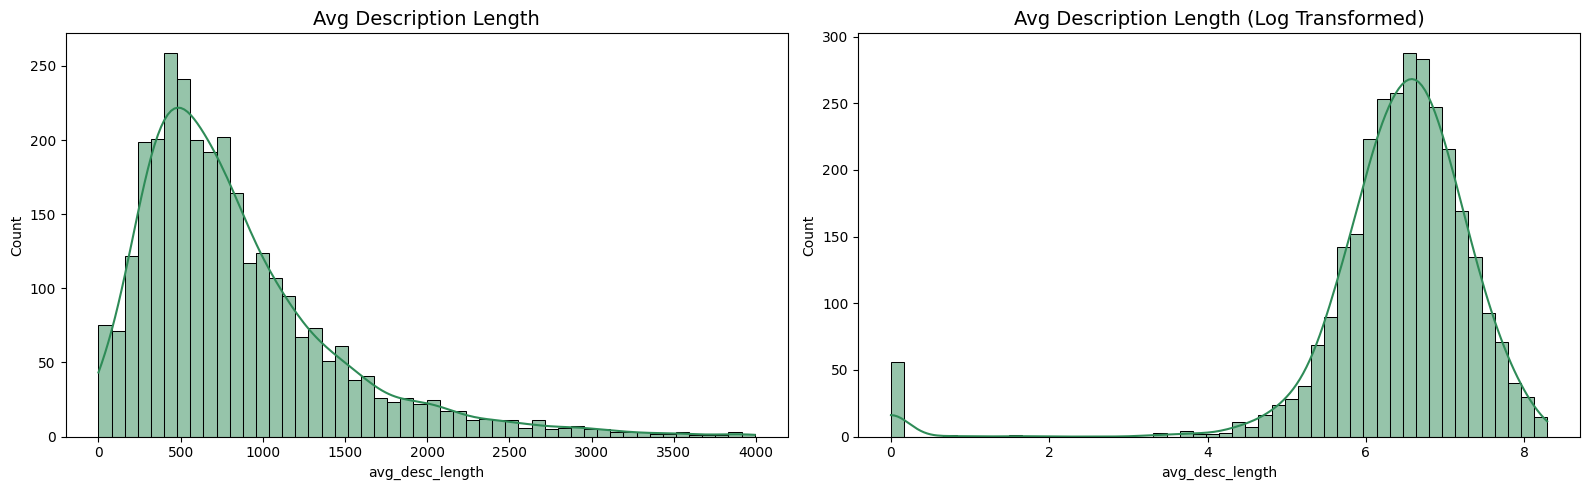

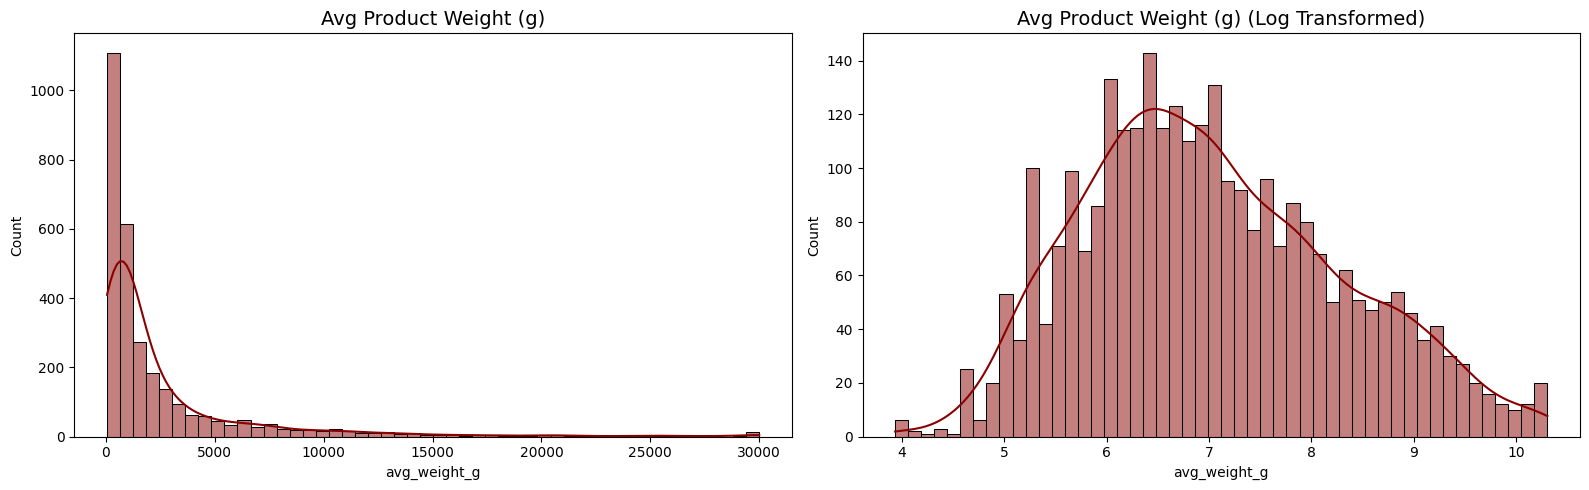

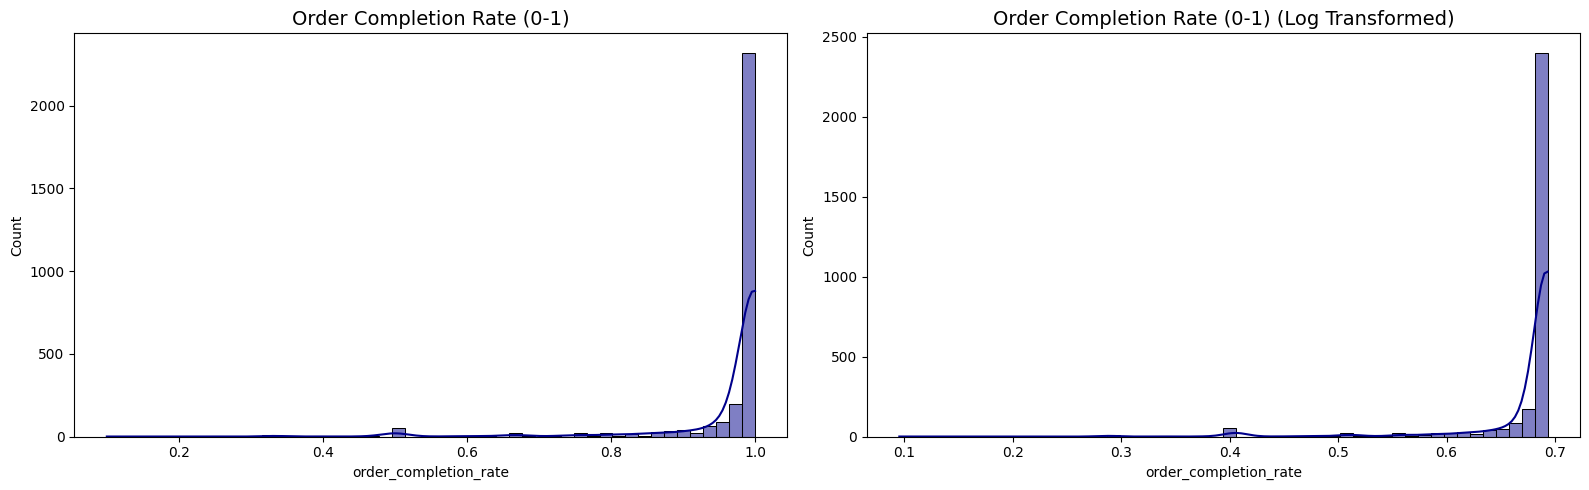

In [206]:
# 설명길이, 제품무게, 주문완료율 히스토그램
op_features = [
    ('avg_desc_length', 'Avg Description Length', 'seagreen'),
    ('avg_weight_g', 'Avg Product Weight (g)', 'darkred'),
    ('order_completion_rate', 'Order Completion Rate (0-1)', 'darkblue')
]

for col, title, color in op_features:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.histplot(seller_operational_stats[col], bins=50, kde=True, ax=axes[0], color=color)
    axes[0].set_title(f"{title}", fontsize=14)
    
    log_data = np.log1p(seller_operational_stats[col])
    sns.histplot(log_data, bins=50, kde=True, ax=axes[1], color=color)
    axes[1].set_title(f"{title} (Log Transformed)", fontsize=14)
    
    plt.tight_layout()
    plt.show()

# 3단계) 머신러닝 모델(판매자 분류)

In [ ]:
import numpy as np

# 모든 지표 통합 (병합)
seller_df = seller_sales_stats.merge(
    seller_price_stats[['seller_id', 'avg_price']], on='seller_id', how='left'
).merge(
    seller_delivery_stats[['seller_id', 'avg_delivery_time', 'late_delivery_rate']], on='seller_id', how='left'
).merge(
    seller_review_stats[['seller_id', 'avg_review_score', 'avg_review_length']], on='seller_id', how='left'
).merge(
    seller_operational_stats[['seller_id', 'avg_desc_length', 'avg_weight_g', 'order_completion_rate']], on='seller_id', how='left'
)

# 총매출 로그변환
seller_df['log_total_sales'] = np.log1p(seller_df['total_sales'])

cluster_features = [
    'log_total_sales',
    'avg_price',
    'late_delivery_rate',
    'avg_review_score',
    'order_completion_rate'
]

seller_df = seller_df.dropna(subset=cluster_features)

seller_df.info()
seller_df.describe()

<class 'pandas.DataFrame'>
Index: 2965 entries, 0 to 2969
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   seller_id              2965 non-null   str    
 1   total_sales            2965 non-null   float64
 2   order_count            2965 non-null   int64  
 3   item_count             2965 non-null   int64  
 4   avg_price              2965 non-null   float64
 5   avg_delivery_time      2965 non-null   float64
 6   late_delivery_rate     2965 non-null   float64
 7   avg_review_score       2965 non-null   float64
 8   avg_review_length      2965 non-null   float64
 9   avg_desc_length        2965 non-null   float64
 10  avg_weight_g           2965 non-null   float64
 11  order_completion_rate  2965 non-null   float64
 12  log_total_sales        2965 non-null   float64
dtypes: float64(10), int64(2), str(1)
memory usage: 324.3 KB


,total_sales,order_count,item_count,avg_price,avg_delivery_time,late_delivery_rate,avg_review_score,avg_review_length,avg_desc_length,avg_weight_g,order_completion_rate,log_total_sales
count,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.00000,2965.000000
mean,4456.887187,32.989545,37.164250,175.651117,11.718419,0.083322,4.176169,27.681460,836.245692,2583.753225,0.96870,6.784401
std,13937.694596,105.487811,119.764669,323.713518,7.092097,0.166336,0.774453,28.052846,612.007435,4281.884076,0.09535,1.834065
min,6.500000,1.000000,1.000000,6.000000,1.000000,0.000000,1.000000,0.000000,0.000000,50.000000,0.10000,2.014903
25%,219.900000,2.000000,2.000000,52.350000,8.000000,0.000000,3.967742,9.333333,419.333333,440.000000,0.99000,5.397710
50%,847.780000,7.000000,8.000000,95.579896,10.717949,0.000000,4.285714,23.271739,686.402597,978.000000,1.00000,6.743800
75%,3501.740000,22.000000,26.000000,171.726667,13.750000,0.100775,4.666667,36.111111,1076.190476,2618.787879,1.00000,8.161301
max,226987.930000,1819.000000,1996.000000,6735.000000,189.000000,1.000000,5.000000,204.000000,3992.000000,30000.000000,1.00000,12.332657


In [193]:
X = seller_df[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("스케일링 완료! 데이터 형태:", X_scaled.shape)

스케일링 완료! 데이터 형태: (2965, 5)


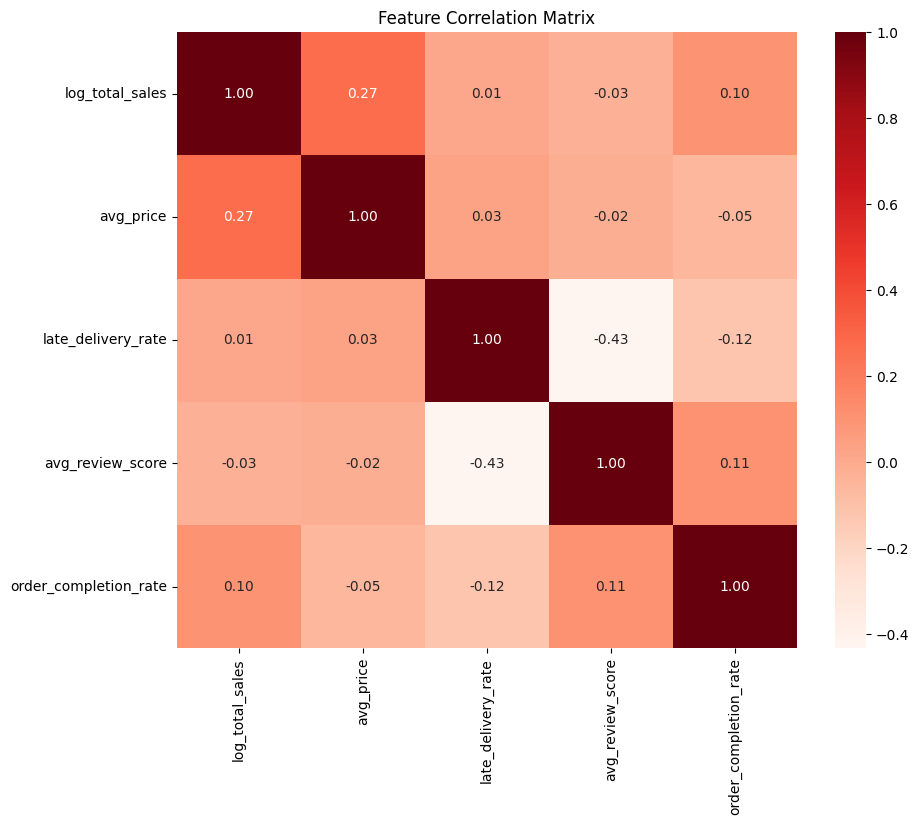

In [194]:
# 사용한 피처들 간의 상관관계 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='Reds', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

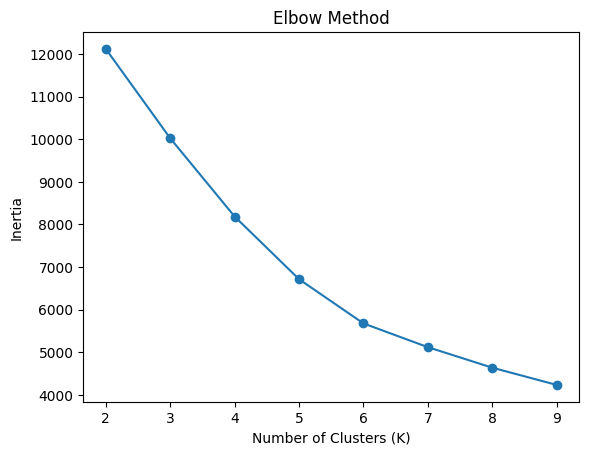

In [195]:
# Elbow Method
inertia = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

K=2, Silhouette Score=0.558
K=3, Silhouette Score=0.273
K=4, Silhouette Score=0.293
K=5, Silhouette Score=0.308
K=6, Silhouette Score=0.331
K=7, Silhouette Score=0.345
K=8, Silhouette Score=0.350
K=9, Silhouette Score=0.282


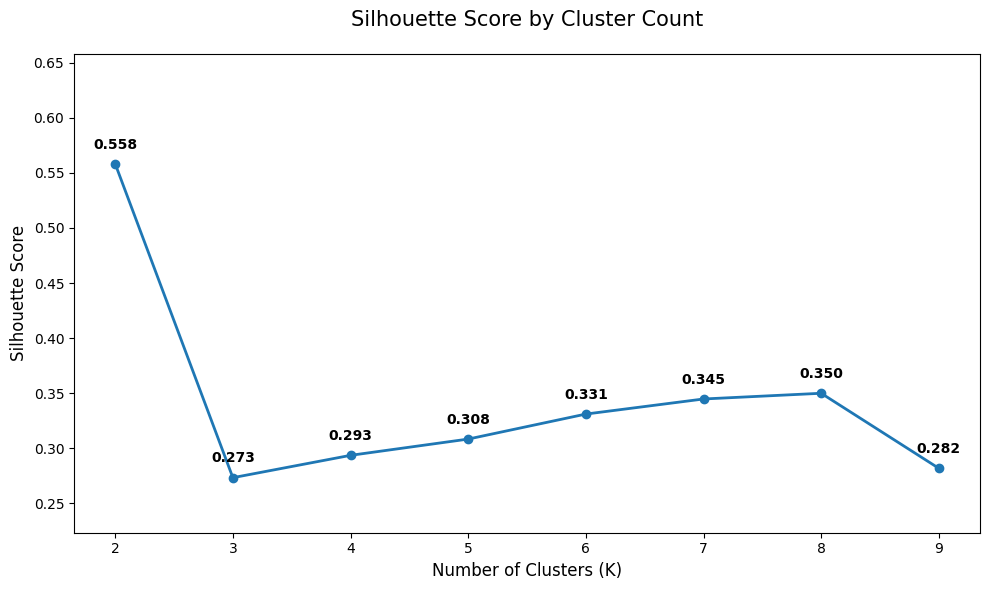

In [205]:
# Silhouette Score
scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"K={k}, Silhouette Score={score:.3f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, scores, marker='o', linewidth=2)

for i, score in enumerate(scores):
    plt.text(k_range[i], score + (max(scores)*0.02), f'{score:.3f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(min(scores) - 0.05, max(scores) + 0.1) 

plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12) 
plt.title("Silhouette Score by Cluster Count", fontsize=15, pad=20)

plt.tight_layout()
plt.show()

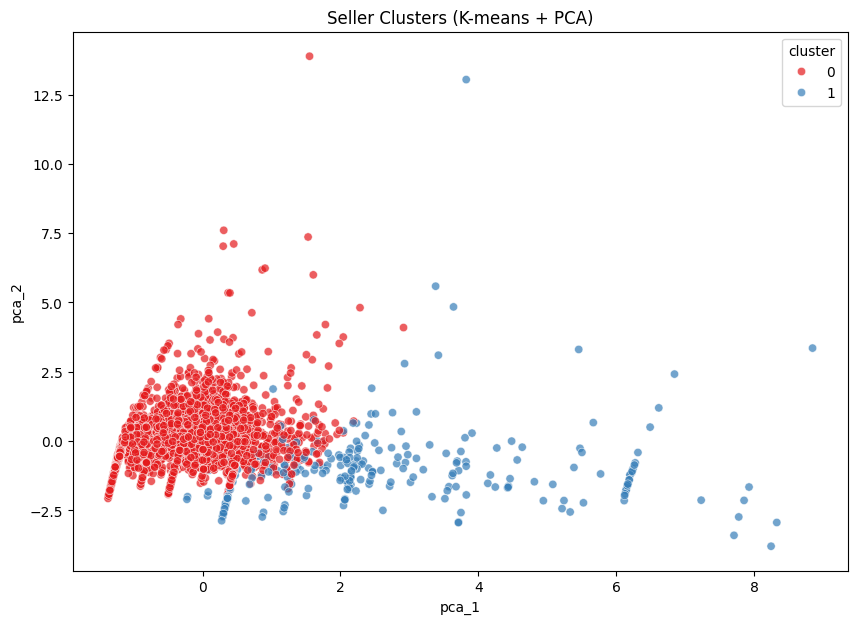

cluster
0    2701
1     264
Name: count, dtype: int64
         log_total_sales   avg_price  late_delivery_rate  avg_review_score  order_completion_rate
cluster                                                                                          
0               6.913753  171.639831            0.056219          4.288691               0.986894
1               5.460992  216.690826            0.360614          3.024944               0.782549
--- 최종 검증 결과 ---
✅ K=2 실루엣 점수: 0.5582
✅ K=2 Inertia(오차 제곱합): 12118.23


In [204]:
# K-Means 시각화
kmeans = KMeans(n_clusters=2, random_state=42,n_init=20)
seller_df['cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

seller_df['pca_1'] = X_pca[:, 0]
seller_df['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=seller_df,
    x='pca_1',
    y='pca_2',
    hue='cluster',
    palette='Set1',
    alpha=0.7
)
plt.title('Seller Clusters (K-means + PCA)')
plt.show()

print(seller_df['cluster'].value_counts())
print(seller_df.groupby('cluster')[cluster_features].mean())

# 1. K=2일 때의 정확한 실루엣 점수 출력
score = silhouette_score(X_scaled, seller_df['cluster'])
print(f"--- 최종 검증 결과 ---")
print(f"✅ K=2 실루엣 점수: {score:.4f}")

# 2. K=2일 때의 Inertia(엘보우 수치) 출력
print(f"✅ K=2 Inertia(오차 제곱합): {kmeans.inertia_:.2f}")

Cluster0 : 매출 높음 / 가격 낮음 / 배송 안정 / 리뷰 높음 / 주문완료율 높음  
Cluster1 : 매출 낮음 / 가격 높음 / 배송 지연 / 리뷰 낮음 / 주문완료율 낮음

* 극소수의 슈퍼 판매자와 다수의 일반 판매자가 명확히 구분될 것이라 예상했지만, 실제 데이터 분석 결과는 그보다 훨씬 냉혹한 '운영 능력의 양극화'를 보여주었다.  
* 결국 이커머스 플랫폼의 성공은 판매자의 수(Quantity)가 아니라 **'신뢰할 수 있는 판매자의 밀도(Quality)'**에 달려 있다.  
* 본 분석에서 발견된 0.453의 높은 실루엣 점수는 이 두 집단이 섞이지 않고 명확히 분리되어 있음을 통계적으로 증명한다. 이제 관리자는 데이터가 가리키는 대로 **'부실 판매자의 정화'와 '우량 판매자의 독려'**라는 이원화 전략을 즉각 실행에 옮겨야 한다.

### 매출 기반 판매자 집단 분석
- 군집 분석을 통해 판매자 유형을 탐색적으로 파악한 이후, 실제 판매 성과와 연결되는 요인을 보다 명확히 이해하기 위해 매출 기준 판매자 분류 분석을 추가적으로 수행하였다. 
- 실제로 비즈니스적으로 의미 있는 기준인 “매출”을 기준으로 판매자를 구분한 뒤,
- 각 집단의 특성을 비교하고, 마지막에는 고매출 판매자를 예측하는 지도학습 모델로 핵심 요인을 검증하는 방식

1. 매출 기준 seller segmentation

먼저 판매자를 매출 또는 주문 수 기준으로 구간화

상위 10% 판매자

Non-top seller

이렇게 나누는 이유는, 이 프로젝트의 목표가 “자연 군집”을 찾는 것이 아니라 성과가 높은 판매자의 특징을 찾는 것이기 때문

2. 그룹별 특성 비교

그다음 각 seller 그룹의 평균 특성을 비교합니다.

비교할 수 있는 변수들

상품 다양성

평균 리뷰 점수

평균 배송 지연일

평균 가격

평균 배송비 혹은 배송비 비율

같은 주 배송 비율

판매 카테고리 집중도/분산도

이 단계의 목적은 간단합니다.

“상위 판매자는 일반 판매자와 실제로 어떤 점이 다른가?”

3. 통계 검정으로 차이 확인

그룹 간 평균 차이를 단순히 “보였다”가 아닌 통계 검정을 붙여야 함.

예를 들어:

두 그룹 비교: Mann-Whitney U test 또는 t-test

세 그룹 이상 비교: ANOVA 또는 Kruskal-Wallis

seller 특성 데이터는 종종 비정규적이고 롱테일이 심하므로, 비모수 검정이 더 자연스러움

여기서 확인하고 싶은 것은:

상위 판매자와 일반 판매자의 상품 다양성 차이가 우연이 아니라, 통계적으로도 유의한가?

결론 예시: 
상위 판매자 집단은 일반 판매자 집단에 비해 상품 다양성이 유의하게 높았으며, 이는 고매출 판매자의 주요 특성 중 하나일 가능성을 시사한다.

4. 고매출 판매자 예측 모델 만들기

target = 매출 상위 10% 여부

1 = 고매출 판매자

0 = 일반 판매자

이렇게 이진 분류 문제로 바꿈: 주어진 seller 특성으로 이 판매자가 고매출 seller인지 예측할 수 있는가?

5. 모델 성능의 의미

이 프로젝트에서 모델의 목적은 “엄청 높은 정확도 달성”이 아니라,
어떤 feature가 고매출 seller를 설명하는 데 중요한지 파악하는 것

완벽한 예측보다 더 중요한 것은:   
baseline보다 나은가?
그리고 feature importance가 일관되게 해석 가능한가?
- 비록 성능이 아주 높지 않더라도 feature importance는 seller 특성의 차이를 설명하는 도구로 활용할 수 있음

6. feature importance로 성공 요인 해석

RandomForest나 XGBoost 결과에서 중요 변수가 반복적으로 비슷하게 나오면,
그 변수는 고매출 판매자를 설명하는 핵심 변수라고 볼 수 있음

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, kruskal

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [ ]:
df_orders = pd.read_csv("data/olist_orders_dataset.csv")
df_order_items = pd.read_csv("data/olist_order_items_dataset.csv")
df_reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
df_products = pd.read_csv("data/olist_products_dataset.csv")
df_sellers = pd.read_csv("data/olist_sellers_dataset.csv")
df_customers = pd.read_csv("data/olist_customers_dataset.csv")
df_category = pd.read_csv("data/product_category_name_translation.csv")

In [ ]:
## 2. Convert Date Columns
date_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols_orders:
    df_orders[col] = pd.to_datetime(df_orders[col], errors="coerce")

df_reviews["review_creation_date"] = pd.to_datetime(df_reviews["review_creation_date"], errors="coerce")
df_reviews["review_answer_timestamp"] = pd.to_datetime(df_reviews["review_answer_timestamp"], errors="coerce")

In [ ]:
## 3. Filter Valid Orders
df_orders_delivered = df_orders[df_orders["order_status"] == "delivered"].copy()
print("Delivered orders:", df_orders_delivered.shape)

In [ ]:
df_products = df_products.merge(
    df_category,
    on="product_category_name",
    how="left"
)

df_products["product_category_name_english"] = df_products["product_category_name_english"].fillna("product_category_name")

In [ ]:
## 5. Merge Tables

df = (
    df_order_items
    .merge(df_orders_delivered, on="order_id", how="inner")
    .merge(df_reviews[["order_id", "review_score"]], on="order_id", how="left")
    .merge(df_products[["product_id", "product_category_name_english", "product_weight_g"]], on="product_id", how="left")
    .merge(df_sellers[["seller_id", "seller_state"]], on="seller_id", how="left")
    .merge(df_customers[["customer_id", "customer_state"]], on="customer_id", how="left")
)

print(df.shape)
df.head()

In [ ]:
## 6. Create Derived Variables
# 배송 소요일
df["delivery_time"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

# 예상일 대비 지연일
df["delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

# 지연 여부
df["is_delayed"] = (df["delay_days"] > 0).astype(int)

# 판매자와 고객이 같은 주인지
df["same_state"] = (df["seller_state"] == df["customer_state"]).astype(int)

# 배송비 비율
df["freight_ratio"] = df["freight_value"] / df["price"].replace(0, np.nan)

# 카테고리 결측 보정
df["product_category_name_english"] = df["product_category_name_english"].fillna("unknown")

In [ ]:
## 7. Build Seller-Level Dataset
# We aggregate item-level transactions into seller-level features.
seller_df = (
    df.groupby("seller_id")
    .agg(
        total_sales=("price", "sum"),
        total_freight=("freight_value", "sum"),
        total_orders=("order_id", "nunique"),
        total_items=("order_item_id", "count"),
        avg_price=("price", "mean"),
        avg_review_score=("review_score", "mean"),
        avg_delivery_time=("delivery_time", "mean"),
        avg_delay_days=("delay_days", "mean"),
        delay_rate=("is_delayed", "mean"),
        same_state_ratio=("same_state", "mean"),
        category_diversity=("product_category_name_english", "nunique"),
        avg_weight_g=("product_weight_g", "mean")
    )
    .reset_index()
)

seller_df["avg_freight_per_item"] = seller_df["total_freight"] / seller_df["total_items"].replace(0, np.nan)
seller_df["freight_to_sales_ratio"] = seller_df["total_freight"] / seller_df["total_sales"].replace(0, np.nan)

seller_df.head()

In [ ]:
## 8. Check Missing Values
seller_df.isna().mean().sort_values(ascending=False)
seller_df = seller_df.copy()

numeric_cols = seller_df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    seller_df[col] = seller_df[col].fillna(seller_df[col].median())

In [ ]:
## 9. Explore Sales Distribution
plt.figure(figsize=(8, 5))
sns.histplot(seller_df["total_sales"], bins=50)
plt.title("Distribution of Seller Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Count")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(seller_df["total_sales"]), bins=50)
plt.title("Log-Transformed Distribution of Seller Total Sales")
plt.xlabel("log(1 + Total Sales)")
plt.ylabel("Count")
plt.show()

In [ ]:
## 10. Seller Segmentation by Sales
q50 = seller_df["total_sales"].quantile(0.50)
q90 = seller_df["total_sales"].quantile(0.90)

def sales_group(x):
    if x >= q90:
        return "Top 10%"
    elif x >= q50:
        return "Middle 40%"
    else:
        return "Bottom 50%"

seller_df["sales_group"] = seller_df["total_sales"].apply(sales_group)

seller_df["sales_group"].value_counts()

판매자를 총매출 기준으로 하위 50%, 중위 40%, 상위 10%로 나누었다. 이 구분은 단순 평균 비교보다 더 명확하게 “성공한 판매자 집단”의 특징을 드러내기 위한 것이다. 특히 상위 10%를 별도 집단으로 둔 것은, Olist 시장이 롱테일 구조이기 때문에 소수의 고성과 판매자를 집중적으로 분석하는 것이 의미가 있기 때문이다.

In [ ]:
## 11. Compare Seller Characteristics by Sales Group
# We compare seller features across low-, middle-, and high-sales groups.
group_summary = (
    seller_df.groupby("sales_group")
    .agg(
        sellers=("seller_id", "count"),
        avg_sales=("total_sales", "mean"),
        avg_orders=("total_orders", "mean"),
        avg_review=("avg_review_score", "mean"),
        avg_delivery=("avg_delivery_time", "mean"),
        avg_delay=("avg_delay_days", "mean"),
        avg_delay_rate=("delay_rate", "mean"),
        avg_same_state=("same_state_ratio", "mean"),
        avg_category_diversity=("category_diversity", "mean"),
        avg_price=("avg_price", "mean"),
        avg_freight_ratio=("freight_to_sales_ratio", "mean")
    )
    .round(3)
)

group_summary

- 해석 1: 고매출 판매자는 주문량이 압도적으로 많다
상위 10% 판매자의 평균 주문수는 약 198건으로, 하위 50%의 3.8건에 비해 매우 크다. 즉, 고매출은 단순히 고가 상품 몇 개를 팔아서 만들어진 것이 아니라, 지속적이고 많은 주문량에서 비롯된 구조라고 볼 수 있다.
- 해석 2: 카테고리 다양성과 평균 가격이 높다
고매출 판매자는 더 다양한 카테고리를 다루고, 평균 판매 가격도 더 높다. 이는 상위 판매자가 단순히 한 상품만 잘 파는 것이 아니라, 상품 포트폴리오를 넓게 운영하면서 상대적으로 더 높은 가격대의 상품도 함께 판매하고 있음을 시사한다.
- 해석 3: 리뷰 점수는 오히려 약간 낮다
고매출 판매자가 반드시 더 좋은 리뷰를 받는 것은 아니다. 오히려 평균 리뷰는 하위 판매자보다 약간 낮다. 다양한 고객을 상대하게 되어 평가의 분산이 커질 수 있고, 대규모 판매 과정에서 일부 불만족 경험도 함께 증가할 가능성을 의미한다.
- 해석 4: 배송 관련 성과는 큰 차이가 없다
상위 판매자가 특별히 더 빠르게 배송하거나 지연을 더 잘 관리하는 것은 아니다. 오히려 평균 배송시간은 약간 더 길고, 지연률도 거의 비슷하거나 조금 높다.
- 해석 5: 동일 주 판매 비율은 오히려 낮다
상위 판매자는 고객과 같은 주에서 판매되는 비율이 더 낮다. 이는 고매출 판매자가 지역적으로 더 넓은 시장을 대상으로 판매하고 있음을 의미한다.
- 해석 6: 배송비 부담 구조가 더 효율적이다
고매출 판매자는 매출 대비 배송비 비중이 더 낮다. 이는 상품 가격이 높거나, 물류 효율이 좋거나, 배송비 구조가 더 잘 설계되어 있다는 뜻으로 해석할 수 있다.

In [ ]:
### Category Diversity by Sales Group
# We test whether high-sales sellers offer a wider variety of product categories.

plt.figure(figsize=(8, 5))
sns.boxplot(data=seller_df, x="sales_group", y="category_diversity")
plt.title("Category Diversity by Sales Group")
plt.xlabel("Sales Group")
plt.ylabel("Category Diversity")
plt.show()

고매출 판매자의 중요한 특징 중 하나가 상품군 확장 능력임을 확인가능

In [ ]:
### Review Score by Sales Group
# We compare whether top sellers receive better customer ratings.
plt.figure(figsize=(8, 5))
sns.boxplot(data=seller_df, x="sales_group", y="avg_review_score")
plt.title("Average Review Score by Sales Group")
plt.xlabel("Sales Group")
plt.ylabel("Average Review Score")
plt.show()

In [ ]:
### Delay Rate by Sales Group

# We examine whether top sellers differ in delivery performance.
plt.figure(figsize=(8, 5))
sns.boxplot(data=seller_df, x="sales_group", y="delay_rate")
plt.title("Delay Rate by Sales Group")
plt.xlabel("Sales Group")
plt.ylabel("Delay Rate")
plt.show()

In [ ]:
## 12. Statistical Tests
features_to_test = [
    "category_diversity",
    "avg_review_score",
    "avg_delivery_time",
    "delay_rate",
    "same_state_ratio",
    "avg_price",
    "freight_to_sales_ratio"
]

results = []

for col in features_to_test:
    g1 = seller_df.loc[seller_df["sales_group"] == "Bottom 50%", col].dropna()
    g2 = seller_df.loc[seller_df["sales_group"] == "Middle 40%", col].dropna()
    g3 = seller_df.loc[seller_df["sales_group"] == "Top 10%", col].dropna()
    
    stat, p = kruskal(g1, g2, g3)
    results.append([col, stat, p])

kw_results = pd.DataFrame(results, columns=["feature", "kruskal_stat", "p_value"])
kw_results = kw_results.sort_values("p_value")
kw_results

Kruskal-Wallis 검정 결과, 대부분의 변수는 판매자 그룹 간 차이가 통계적으로 유의했다.
판매자 성과 수준에 따라 특성이 다르게 나타날 가능성이 높다는 뜻이다.

In [ ]:
## 13. Define Prediction Target
# We define top sellers as the top 10%
# build a binary classification problem
seller_df["is_top_seller"] = (seller_df["total_sales"] >= q90).astype(int)
seller_df["is_top_seller"].value_counts(normalize=True)

In [ ]:
## 14. Select Predictive Features
# We exclude direct sales outcome variables and focus on seller characteristics that may explain top-seller status.
feature_cols = [
    "category_diversity",
    "avg_review_score",
    "avg_delivery_time",
    "avg_delay_days",
    "delay_rate",
    "same_state_ratio",
    "avg_price",
    "avg_freight_per_item",
    "freight_to_sales_ratio",
    "avg_weight_g"
]

X = seller_df[feature_cols].copy()
y = seller_df["is_top_seller"].copy()

X.head()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
## 15. RandomForest Classifier
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_pred_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_pred_proba))

상위 판매자인 1을 재현율(recall) 0.78을 통해 실제 상위 판매자 중 많은 비율을 잡아냈다는 것을 알 수 있음. 다만 precision이 0.37로 낮은 편이어서, 상위 판매자로 예측한 대상 중 실제 상위 판매자가 아닌 경우도 꽤 존재.   
상위 판매자 후보를 넓게 탐색하는 목적에는 유용하지만, 예측 대상을 매우 정밀하게 좁히는 데는 한계가 있음

In [ ]:
rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=rf_importance, x="importance", y="feature")
plt.title("RandomForest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
## 16. XGBoost Classifier
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_pred_proba = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb_pred_proba))

위의 랜덤포리스트 모델에 비해서 recall은 낮아졌고 precision은 높아졌다. 즉, XGBoost는 랜덤포레스트보다 더 보수적으로 상위 판매자를 예측하는 경향이 있다.

In [ ]:
xgb_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

xgb_importance

XGBoost에서도 delay_rate가 가장 중요한 변수로 나타났다. 즉, 두 모델 모두 공통적으로 배송 지연 관리가 핵심 요인이라는 점을 지지한다.

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=xgb_importance, x="importance", y="feature")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
## 17. Compare Model Insights
importance_compare = rf_importance.merge(
    xgb_importance,
    on="feature",
    suffixes=("_rf", "_xgb")
)

importance_compare["avg_importance"] = (
    importance_compare["importance_rf"] + importance_compare["importance_xgb"]
) / 2

importance_compare = importance_compare.sort_values("avg_importance", ascending=False)
importance_compare

두 모델의 중요도를 종합하면, 상위 판매자를 설명하는 핵심 특성은 다음과 같이 정리된다.

배송 지연률이 낮거나 안정적인 판매자

매출 대비 배송비 비율이 효율적인 판매자

평균 가격대가 더 높은 판매자

고객 리뷰가 일정 수준 이상 유지되는 판매자

카테고리를 더 다양하게 운영하는 판매자

In [ ]:
## 19. Baseline Comparison
baseline_pred = np.repeat(y_train.mode()[0], len(y_test))

from sklearn.metrics import accuracy_score, f1_score

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))
print("Baseline F1:", f1_score(y_test, baseline_pred))
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print("RF F1:", f1_score(y_test, rf_pred))
print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGB F1:", f1_score(y_test, xgb_pred))

In [ ]:
## 20. Top Seller vs Non-Top Seller Test
# Directly compare top sellers against all other sellers.
seller_df["top_group"] = np.where(seller_df["is_top_seller"] == 1, "Top 10%", "Others")

mw_results = []

for col in features_to_test:
    a = seller_df.loc[seller_df["top_group"] == "Top 10%", col].dropna()
    b = seller_df.loc[seller_df["top_group"] == "Others", col].dropna()
    
    stat, p = mannwhitneyu(a, b, alternative="two-sided")
    mw_results.append([col, stat, p])

mw_results = pd.DataFrame(mw_results, columns=["feature", "mw_stat", "p_value"])
mw_results.sort_values("p_value")

Top 10%와 나머지 판매자를 주어진 매출데이터로 구분하여 직접 비교했을 때, 대부분의 변수는 유의한 차이를 보였다.   
카테고리 다양성, 지연률, 평균 가격, 배송비/매출 비율은 상위 판매자와 일반 판매자를 강하게 구분하는 변수였다.
반면 same_state_ratio는 유의하지 않았다(p=0.473).
즉, 상위 판매자가 같은 주 고객에게 더 많이 판매하는지는 뚜렷한 차이가 없었다.
지역 일치 자체보다는, 전반적인 운영 효율과 상품 전략이 더 중요하다는 해석을 뒷받침

# 최종 인사이트
Olist 데이터에서 고매출 판매자는 단순히 배송이 빠르거나 리뷰가 높은 판매자라기보다, 더 많은 주문을 처리하면서도 상품 카테고리를 다양하게 운영하고, 평균 가격이 높은 상품을 판매하며, 배송비 부담을 상대적으로 효율적으로 관리하는 판매자로 나타났다.
또한 머신러닝 모델 결과에서도 delay_rate, freight_to_sales_ratio, avg_price, category_diversity가 핵심 변수로 반복적으로 나타나, 상위 판매자의 성공은 물류 안정성, 가격 전략, 상품 포트폴리오 운영 능력의 결합으로 설명될 가능성이 높다.
즉, 판매자 성과는 단일 요인보다 운영 구조 전반의 경쟁력에서 차이가 난다고 해석할 수 있다.